In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [7]:
import cil_regionalization as cilreg
from cil_regionalization.config import SourceUnitPolicies

DATA = Path("/home/emily_zuetell/projects/poreallas/data")
DATA_VERSION = "world-combo-201710"  # the impact region version of the sample

In [3]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]

In [4]:
# Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated=False)
baseline_period = analysis_utils.get_baseline_period(effect, years=30)
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

In [8]:
def ir_to_adm1(
    effect,
    polygons,
    rate=False,
    hotonly="net",
    monthly=True,
    dims=["number", "sample"],
    operation="median",
):
    # Compute the Mortality Impact relative to a Baseline Period for the Projected Effects
    impact = analysis_utils.compute_impact(
        effect,
        socioeconomics,
        ensemble=True,
        baseline_period=baseline_period,
        hotonly=hotonly,
        rate=rate,
        age_weight=True,
    )

    if not monthly:
        impact_s = impact.sum(dim="month")
    else:
        impact_s = impact

    if operation == "median":
        impact_s = impact_s.median(dim=dims)
    elif operation == "mean":
        impact_s = impact_s.mean(dim=dims)

    _polygons_impact = analysis_utils.xarray_to_gpd(impact_s, polygons)
    shapes = gpd.read_parquet(DATA / "adm1.parquet")
    # names = shapes[["ISO", "ID_1", "NAME_1"]]
    names = shapes[["GID_0", "GID_1", "NAME_1"]]
    # Total Deaths: "per_source", "kind = extensive"
    # Death Rates: "per_destination", "kind = intensive"
    if rate:
        weights = cilreg.fetch_weights("gadm41-adm1-per-destination")
    else:
        weights = cilreg.fetch_weights("gadm41-adm1-per-source")

    damages = (
        _polygons_impact[["region", "month", "age_weighted_impact"]]
        if monthly
        else _polygons_impact[["region", "age_weighted_impact"]]
    )
    damages = damages.rename(columns={"region": "hierid"})
    col_regions = {(h,) for h in damages["hierid"].unique()}
    # allow_partial_coverage=True to handle coastal geometry
    kind = "intensive" if rate else "extensive"

    _damages = damages
    adm1 = cilreg.apply_weights(
        weights,
        _damages,
        kind=kind,
        weight="pop",
        value_col="age_weighted_impact",
        data_version=DATA_VERSION,
        restrict_to_sources=col_regions,
        allow_partial_coverage=True,
        policies=SourceUnitPolicies(on_unmatched="skip", on_zero_weight="skip"),
    ).frame

    m = shapes.merge(adm1, on=["GID_0", "GID_1"])

    return m

In [23]:
m = ir_to_adm1(
    effect,
    _polygons,
    rate=False,
    hotonly="coldonly",
    monthly=True,
    dims=["number", "sample"],
    operation="median",
)
m["age_weighted_impact"] = m["age_weighted_impact"].astype(int)

In [18]:
m.pivot(index=["GID_0", "GID_1"], columns="month", values="age_weighted_impact")

month           1   8   9   10  11  12
GID_0 GID_1                           
ABW             -2  -1   0  -1  -1  -1
AFG   AFG.10_1   0  -2   0  -4  -3   0
      AFG.11_1  -9 -49  -1  -6 -23 -16
      AFG.12_1  -8 -47 -11 -23 -30 -20
      AFG.13_1  -3  -8  -4 -11  -4  -6
...             ..  ..  ..  ..  ..  ..
ZWE   ZWE.5_1  -13  27   0   1   3 -10
      ZWE.6_1   -3  32   0  10  25  -5
      ZWE.7_1   30  57   7   0  -1   1
      ZWE.8_1   12  20   0   4  26  10
      ZWE.9_1   16  25   2   0   2   3

[3671 rows x 6 columns]

In [24]:
m[["GID_0", "GID_1", "NAME_0", "NAME_1", "month", "age_weighted_impact"]].to_csv(
    "2608_monthly_coldonly_total_median_adm1.csv"
)

<Axes: >

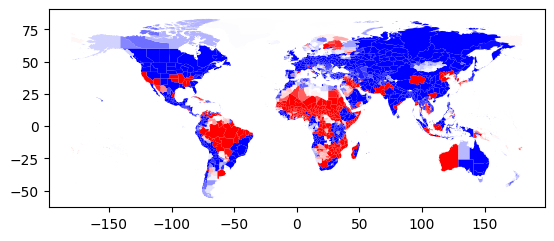

In [7]:
m.plot(column="age_weighted_impact", vmin=-15, vmax=15, cmap="bwr")

# Validation

In [ ]:
# Compare totals for IR and ADM1
for iso in ["AUS"]:
    adm1_iso = m[m["GID_0"] == iso]["age_weighted_impact"].sum()
    ir_iso = _polygons_impact[_polygons_impact["ISO"] == iso][
        "age_weighted_impact"
    ].sum()
    print(f"{iso}\nIR Total: {ir_iso}\n ADM1 Total: {adm1_iso}")

<Axes: >

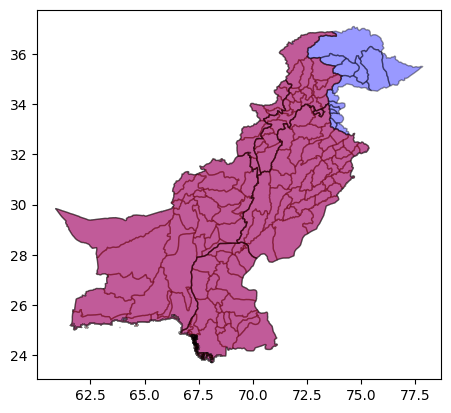

In [ ]:
# Compare Geometry Outlines
iso = "PAK"
fig, ax = plt.subplots()
_polygons_impact[_polygons_impact["ISO"] == iso].to_crs("WGS 84").plot(
    color="blue", alpha=0.4, edgecolor="k", ax=ax
)
m[m["GID_0"] == iso].plot(color="red", edgecolor="k", alpha=0.4, ax=ax)

<Axes: >

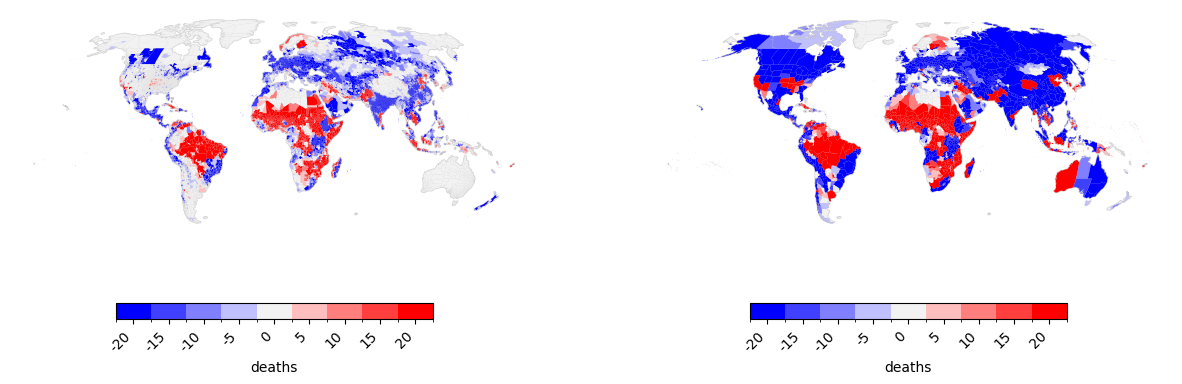

In [ ]:
# Compare Maps
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

analysis_utils.plot_single(
    _polygons_impact,
    col="age_weighted_impact",
    cm="bwr",
    n_colors=10,
    vmin=-20,
    vmax=20,
    sup_title="",
    cbar_label="deaths/100k" if rate else "deaths",
    cbar_location="bottom",
    ax=axs[0],
)

analysis_utils.plot_single(
    m,
    col="age_weighted_impact",
    cm="bwr",
    n_colors=10,
    vmin=-20,
    vmax=20,
    sup_title="",
    cbar_label="deaths/100k" if rate else "deaths",
    cbar_location="bottom",
    ax=axs[1],
)